# Модель Лотки-Вольтерры

### Данная модель описывает взаимодейстивия двух популяций в экосистеме. Классический пример- взаимодействие хищника и жертвы. Кроме того, модель является одной из базовых в области математической биологии и используется для анализа колебаний численности популяций.

## Код модели

In [1]:
using DrWatson
@quickactivate

using DifferentialEquations
using DataFrames
using StatsPlots
using LaTeXStrings
using Plots
using Statistics
using FFTW

script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

"/home/nurislam/.julia/environments/v1.12/data/"

# Описание модели Лотки–Вольтерры

““” Модель Лотки-Вольтерры (хищник-жертва)

Система уравнений:

dx/dt = αx - βxy \# Изменение популяции жертв dy/dt = δxy - γy \#
Изменение популяции хищников

Где:

x - популяция жертв (например, зайцы) y - популяция хищников (например,
лисы) α - естественный прирост жертв (в отсутствие хищников) β -
коэффициент поедания жертв хищниками δ - коэффициент прироста хищников
за счет поедания жертв γ - естественная смертность хищников (в
отсутствие жертв) ““”

In [2]:
function lotka_volterra!(du, u, p, t)
x, y = u
# x - жертвы, y - хищники
α, β, δ, γ = p
# параметры модели

@inbounds begin
du[1] = α*x - β*x*y
# уравнение для жертв
du[2] = δ*x*y - γ*y
# уравнение для хищников
end
nothing
end

lotka_volterra! (generic function with 1 method)

# Параметры модели и начальные условия

# Классические параметры из литературы

In [3]:
p_lv = [0.1,
# α: скорость размножения жертв
0.02,
# β: скорость поедания жертв хищниками
0.01,
# δ: коэффициент конверсии пищи (жертв) в хищников
0.3]
# γ: смертность хищников

4-element Vector{Float64}:
 0.1
 0.02
 0.01
 0.3

# Начальные условия: \[жертвы, хищники\]

In [4]:
u0_lv = [40.0, 9.0]

2-element Vector{Float64}:
 40.0
  9.0

# начальная популяция

# Временные параметры

In [5]:
tspan_lv = (0.0, 200.0)

(0.0, 200.0)

# длительность симуляции

In [6]:
dt_lv = 0.01

0.01

# шаг интегрирования

# Создание и решение задачи

In [7]:
prob_lv = ODEProblem(lotka_volterra!, u0_lv, tspan_lv, p_lv)
sol_lv = solve(prob_lv,
dt = dt_lv,
Tsit5(),
# Метод 5-го порядка
reltol=1e-8,
# Относительная точность
abstol=1e-10,
# Абсолютная точность
saveat=0.1,
# Сохраняем каждые 0.1 единицы времени
dense=true
# Включаем плотный вывод для интерполяции
)

retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 2001-element Vector{Float64}:
   0.0
   0.1
   0.2
   0.3
   0.4
   0.5
   0.6
   0.7
   0.8
   0.9
   1.0
   1.1
   1.2
   ⋮
 198.9
 199.0
 199.1
 199.2
 199.3
 199.4
 199.5
 199.6
 199.7
 199.8
 199.9
 200.0
u: 2001-element Vector{Vector{Float64}}:
 [40.0, 9.0]
 [39.67773201890384, 9.088990237207637]
 [39.35113789503168, 9.175882726306998]
 [39.02053587808482, 9.260562174341327]
 [38.68624820281499, 9.342916311942014]
 [38.34860018759226, 9.422836265415745]
 [38.007919320045765, 9.5002169187062]
 [37.664534369328166, 9.574957250330058]
 [37.31877446654823, 9.646960666854817]
 [36.9709682176784, 9.716135308317774]
 [36.62144287329974, 9.782394321389948]
 [36.270523365122514, 9.845656154267312]
 [35.91853163311434, 9.905844751305578]
 ⋮
 [17.88967563421412, 5.712401894068302]
 [17.86543624231875, 5.643570483722269]
 [17.843673453877365, 5.5754402198919735]
 [17.824353144929315, 5.508019318506856]
 [17.8074420

# Подготовка данных

In [8]:
df_lv = DataFrame()
df_lv[!, :t] = sol_lv.t
df_lv[!, :prey] = [u[1] for u in sol_lv.u]
# жертвы
df_lv[!, :predator] = [u[2] for u in sol_lv.u]
# хищники

2001-element Vector{Float64}:
 9.0
 9.088990237207637
 9.175882726306998
 9.260562174341327
 9.342916311942014
 9.422836265415745
 9.5002169187062
 9.574957250330058
 9.646960666854817
 9.716135308317774
 9.782394321389948
 9.845656154267312
 9.905844751305578
 ⋮
 5.712401894068302
 5.643570483722269
 5.5754402198919735
 5.508019318506856
 5.441315154551648
 5.375334300040311
 5.310082577777411
 5.24556508481173
 5.181786245480946
 5.118749811721092
 5.056458873592464
 4.994915937053478

# Рассчет производных для анализа

In [9]:
df_lv[!, :dprey_dt] = p_lv[1] .* df_lv.prey .- p_lv[2] .* df_lv.prey .* df_lv.predator
df_lv[!, :dpredator_dt] = p_lv[3] .* df_lv.prey .* df_lv.predator .- p_lv[4] .* df_lv.predator

2001-element Vector{Float64}:
  0.9000000000000004
  0.8796081183812872
  0.8580494468233599
  0.8353523334488111
  0.8115489002365717
  0.7866749261310111
  0.7607697060793308
  0.7338758893000268
  0.706039294083721
  0.677308704329461
  0.6477356516317538
  0.6173741696029547
  0.5862805551332175
  ⋮
 -0.6917903984489675
 -0.6848226585569588
 -0.6777687195139261
 -0.6706369809304658
 -0.6634355041663761
 -0.6561720201747897
 -0.648853939485278
 -0.6414883588865488
 -0.6340820722589682
 -0.6266415740257949
 -0.6191730642026259
 -0.611682463105866

# Вывод информации о модели

In [10]:
println("="^60)
println("Модель Лотки-Вольтерры (хищник-жертва)")
println("="^60)
println("\nПараметры модели:")
println("α (скорость размножения жертв) = ", p_lv[1])
println("β (скорость поедания жертв) = ", p_lv[2])
println("δ (коэффициент конверсии) = ", p_lv[3])
println("γ (смертность хищников) = ", p_lv[4])
println("\nНачальные условия:")
println("Жертвы (x0) = ", u0_lv[1])
println("Хищники (y0) = ", u0_lv[2])

Модель Лотки-Вольтерры (хищник-жертва)

Параметры модели:
α (скорость размножения жертв) = 0.1
β (скорость поедания жертв) = 0.02
δ (коэффициент конверсии) = 0.01
γ (смертность хищников) = 0.3

Начальные условия:
Жертвы (x0) = 40.0
Хищники (y0) = 9.0

# Стационарные точки (нулевые изоклины)

In [11]:
x_star = p_lv[4] / p_lv[3]
# стационарная точка для жертв
y_star = p_lv[1] / p_lv[2]
# стационарная точка для хищников
println("\nСтационарные точки (положения равновесия):")
println("x* = γ/δ = ", round(x_star, digits=3))
println("y* = α/β = ", round(y_star, digits=3))


Стационарные точки (положения равновесия):
x* = γ/δ = 30.0
y* = α/β = 5.0

# Построение графиков

# График 1: Динамика популяций во времени


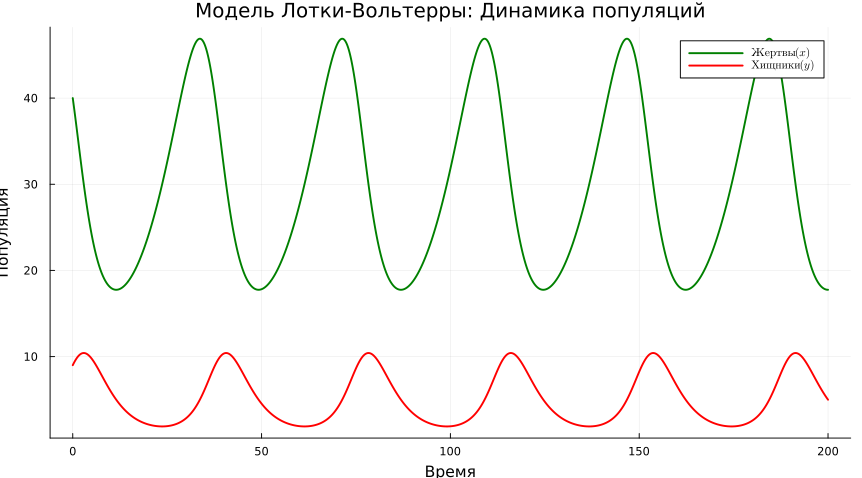

In [12]:
plt1 = plot(df_lv.t, [df_lv.prey df_lv.predator],
label=[L"Жертвы (x)" L"Хищники (y)"],
xlabel="Время",
ylabel="Популяция",
title="Модель Лотки-Вольтерры: Динамика популяций",
linewidth=2,
legend=:topright,
grid=true,
size=(900, 500),
color=[:green :red])

# Добавление стационарных уровней


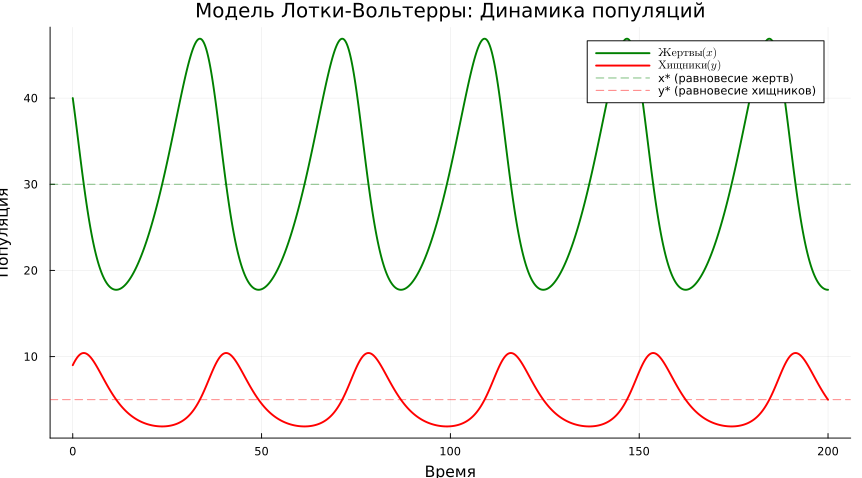

In [13]:
hline!(plt1, [x_star], color=:green, linestyle=:dash, alpha=0.5,
label="x* (равновесие жертв)")
hline!(plt1, [y_star], color=:red, linestyle=:dash, alpha=0.5,
label="y* (равновесие хищников)")

# График 2: Фазовый портрет (хищники vs жертвы)


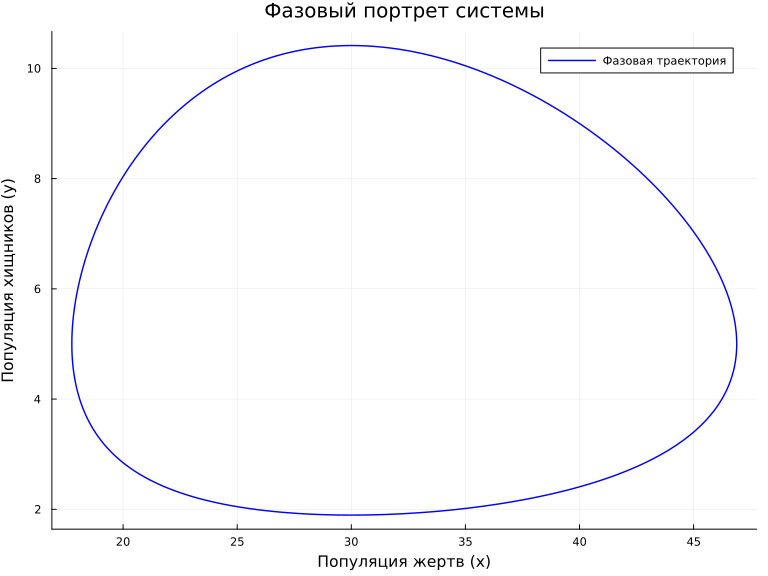

In [14]:
plt2 = plot(df_lv.prey, df_lv.predator,
label="Фазовая траектория",
xlabel="Популяция жертв (x)",
ylabel="Популяция хищников (y)",
title="Фазовый портрет системы",
color=:blue,
linewidth=1.5,
grid=true,
size=(800, 600),
legend=:topright)

# Добавление стрелок направления на фазовом портрете

In [15]:
step = 50
# шаг для отображения стрелок
for i in 1:step:length(df_lv.prey)-step
plot!(plt2, [df_lv.prey[i], df_lv.prey[i+step]],
[df_lv.predator[i], df_lv.predator[i+step]],
arrow=:closed, color=:blue, alpha=0.3, label=false)
end

# Добавление стационарной точки


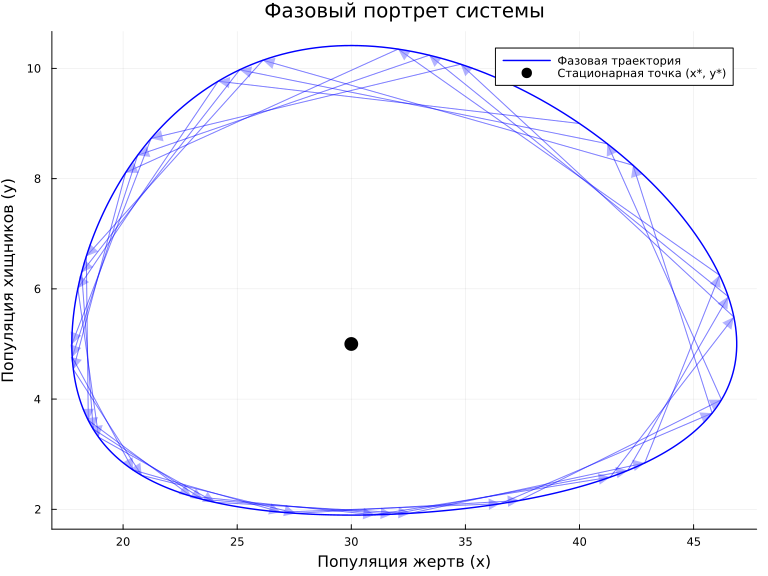

In [16]:
scatter!(plt2, [x_star], [y_star],
color=:black, markersize=8, label="Стационарная точка (x*, y*)")

# Изоклины (нулевого роста)


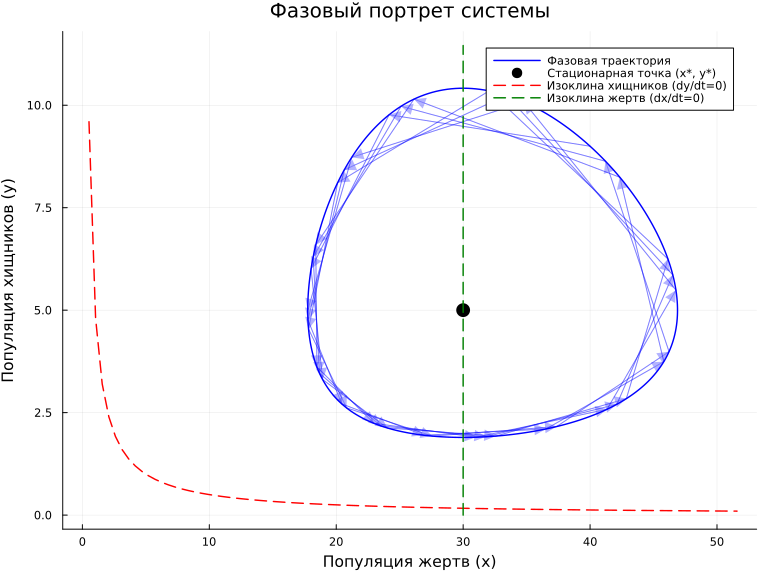

In [17]:
x_range = LinRange(0, maximum(df_lv.prey)*1.1, 100)
y_nullcline = p_lv[1] ./ (p_lv[2] .* x_range)
# y-изоклина (dy/dt = 0)
plot!(plt2, x_range, y_nullcline,
color=:red, linestyle=:dash, linewidth=1.5, label="Изоклина хищников (dy/dt=0)")

y_range = LinRange(0, maximum(df_lv.predator)*1.1, 100)
x_nullcline = p_lv[4] ./ (p_lv[3] .* ones(length(y_range)))
# x-изоклина (dx/dt = 0)
plot!(plt2, x_nullcline, y_range,
color=:green, linestyle=:dash, linewidth=1.5, label="Изоклина жертв (dx/dt=0)")

# График 3: Производные (скорости изменения)


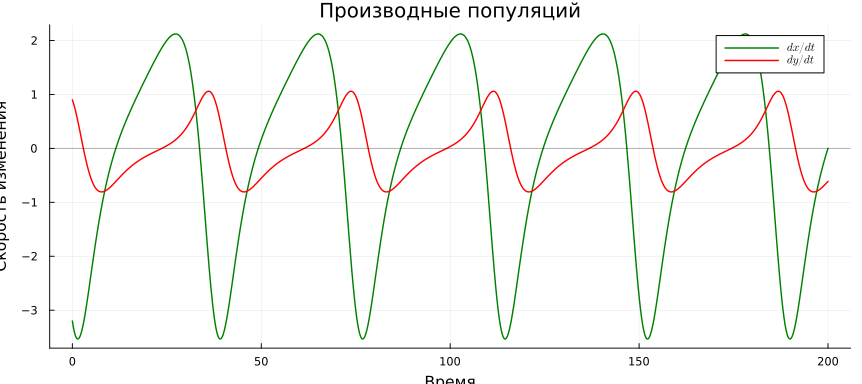

In [18]:
plt3 = plot(df_lv.t, [df_lv.dprey_dt df_lv.dpredator_dt],
label=[L"dx/dt" L"dy/dt"],
xlabel="Время",
ylabel="Скорость изменения",
title="Производные популяций",
linewidth=1.5,
legend=:topright,
grid=true,
size=(900, 400),
color=[:green :red])

hline!(plt3, [0], color=:black, linestyle=:solid, alpha=0.3,
label=false)

# График 4: Относительные изменения (в %)


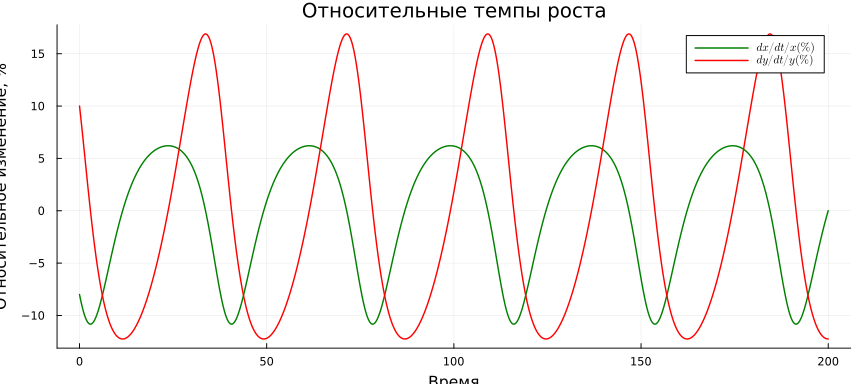

In [19]:
df_lv[!, :prey_pct_change] = df_lv.dprey_dt ./ df_lv.prey .* 100
df_lv[!, :predator_pct_change] = df_lv.dpredator_dt ./ df_lv.predator .* 100

plt4 = plot(df_lv.t, [df_lv.prey_pct_change df_lv.predator_pct_change],
label=[L"dx/dt / x (\%)" L"dy/dt / y (\%)"],
xlabel="Время",
ylabel="Относительное изменение, %",
title="Относительные темпы роста",
linewidth=1.5,
legend=:topright,
grid=true,
size=(900, 400),
color=[:green :red])

# График 5: Спектральный анализ (быстрое преобразование Фурье)

In [20]:
function compute_fft(signal, dt)
n = length(signal)
# Используем rfft для вещественных сигналов (возвращает только положительные частоты)
spectrum = abs.(rfft(signal))
# Соответствующие частоты для rfft
freq = rfftfreq(n, 1/dt)
return freq, spectrum
end

compute_fft (generic function with 1 method)

# Вычисление периодов колебаний


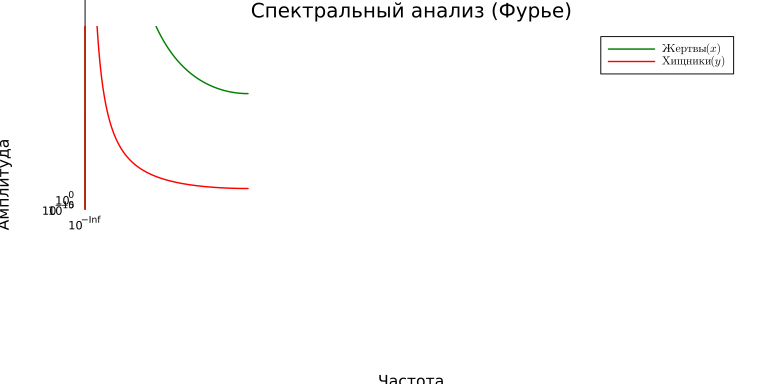

In [21]:
freq_prey, spectrum_prey = compute_fft(df_lv.prey .- mean(df_lv.prey), dt_lv)
freq_predator, spectrum_predator = compute_fft(df_lv.predator .- mean(df_lv.predator), dt_lv)

plt5 = plot(freq_prey, [spectrum_prey spectrum_predator],
label=[L"Жертвы (x)" L"Хищники (y)"],
xlabel="Частота",
ylabel="Амплитуда",
title="Спектральный анализ (Фурье)",
linewidth=1.5,
xscale=:log10,
yscale=:log10,
legend=:topright,
grid=true,
size=(800, 400),
color=[:green :red])

# Нахождение доминирующих частот

In [22]:
if length(spectrum_prey) > 0
idx_prey = argmax(spectrum_prey[2:end]) + 1
# пропускаем нулевую частоту
dominant_freq_prey = freq_prey[idx_prey]
period_prey = 1/dominant_freq_prey
println("\nДоминирующая частота колебаний жертв: ",
round(dominant_freq_prey, digits=4), " Гц")
println("Период колебаний жертв: ", round(period_prey,
digits=2), " единиц времени")
end


Доминирующая частота колебаний жертв: 0.2499 Гц
Период колебаний жертв: 4.0 единиц времени

# График 6: Компактная панель всех графиков


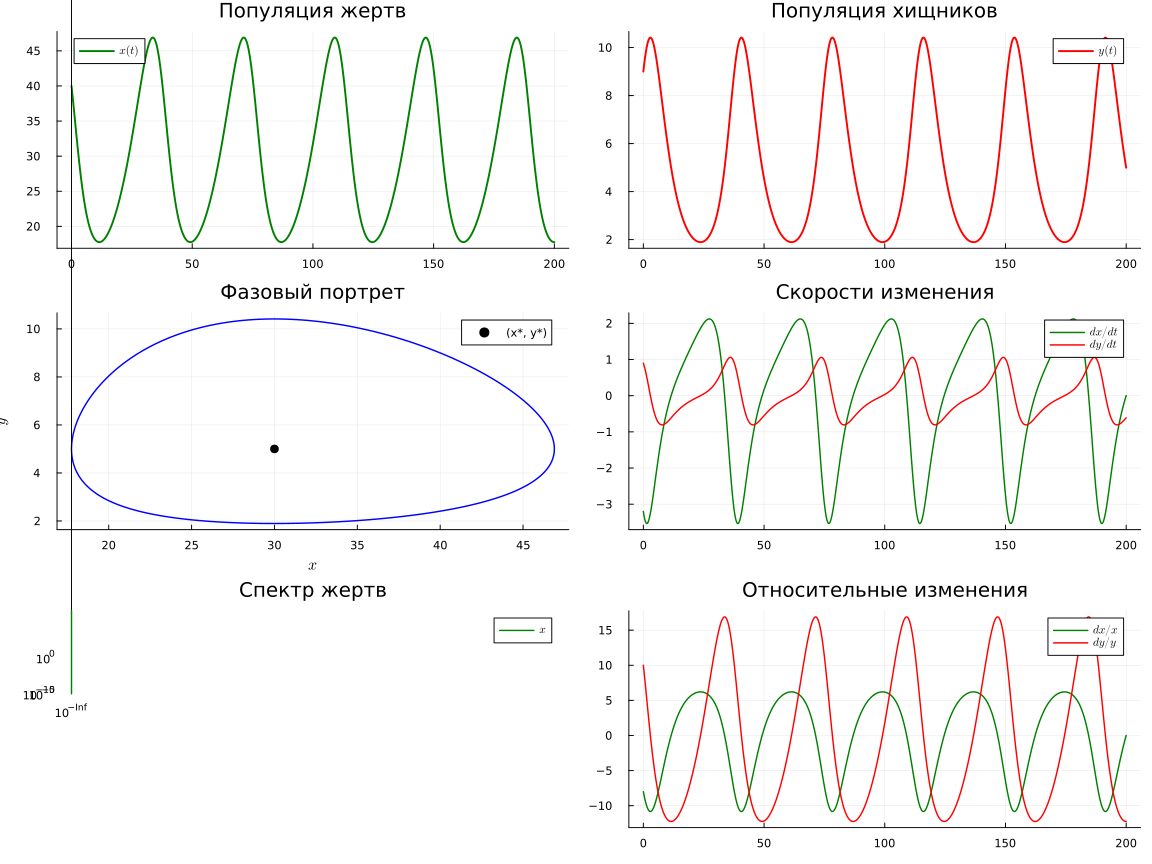

In [23]:
plt6 = plot(layout=(3, 2), size=(1200, 900))

plot!(plt6[1], df_lv.t, df_lv.prey, label=L"x(t)", color=:green,
linewidth=2, title="Популяция жертв", grid=true)
plot!(plt6[2], df_lv.t, df_lv.predator, label=L"y(t)", color=:red,
linewidth=2, title="Популяция хищников", grid=true)
plot!(plt6[3], df_lv.prey, df_lv.predator, label=false, color=:blue, linewidth=1.5,
title="Фазовый портрет", xlabel=L"x", ylabel=L"y", grid=true)
scatter!(plt6[3], [x_star], [y_star], color=:black, markersize=5,

label="(x*, y*)")
plot!(plt6[4], df_lv.t, [df_lv.dprey_dt df_lv.dpredator_dt],
label=[L"dx/dt" L"dy/dt"], color=[:green :red], linewidth=1.5,
title="Скорости изменения", grid=true, legend=:topright)
plot!(plt6[5], freq_prey, spectrum_prey, label=L"x", color=:green,
linewidth=1.5, title="Спектр жертв", xscale=:log10, yscale=:log10, grid=true)
plot!(plt6[6], df_lv.t, [df_lv.prey_pct_change df_lv.predator_pct_change],
label=[L"dx/x" L"dy/y"], color=[:green :red], linewidth=1.5,
title="Относительные изменения", grid=true, legend=:topright)

# Анализ результатов

In [24]:
println("\n" * "="^60)
println("Анализ результатов")
println("="^60)

println("\nОсновные статистики:")
println("Жертвы: min = ", round(minimum(df_lv.prey), digits=2),
", max = ", round(maximum(df_lv.prey), digits=2),
", mean = ", round(mean(df_lv.prey), digits=2))
println("Хищники: min = ", round(minimum(df_lv.predator), digits=2),
", max = ", round(maximum(df_lv.predator), digits=2),
", mean = ", round(mean(df_lv.predator), digits=2))


Анализ результатов

Основные статистики:
Жертвы: min = 17.75, max = 46.89, mean = 29.71
Хищники: min = 1.9, max = 10.41, mean = 5.2

Упрощенный анализ колебаний без поиска максимумов Вместо сложного
анализа сдвига фаз, просто посчитаем основные характеристики

Находим время первого пика жертв (простой алгоритм)

In [25]:
function find_first_peak(signal, time)
for i in 2:length(signal)-1
if signal[i] > signal[i-1] && signal[i] > signal[i+1]
return time[i], signal[i]
end
end
return NaN, NaN
end

peak_time_prey, peak_value_prey = find_first_peak(df_lv.prey,
df_lv.t)
peak_time_predator, peak_value_predator = find_first_peak(df_lv.predator, df_lv.t)

if !isnan(peak_time_prey) && !isnan(peak_time_predator)
phase_shift = peak_time_predator - peak_time_prey
println("\nАнализ колебаний:")
println("Первый пик жертв: время = ", round(peak_time_prey,
digits=2),
", значение = ", round(peak_value_prey, digits=2))
println("Первый пик хищников: время = ",
round(peak_time_predator, digits=2),
", значение = ", round(peak_value_predator, digits=2))
println("Сдвиг фаз (хищники отстают): ", round(phase_shift,
digits=2))
end


Анализ колебаний:
Первый пик жертв: время = 33.7, значение = 46.89
Первый пик хищников: время = 2.9, значение = 10.41
Сдвиг фаз (хищники отстают): -30.8

# Сохранение графиков

In [26]:
savefig(plt1, plotsdir(script_name, "lv_dynamics.png"))
savefig(plt2, plotsdir(script_name, "lv_phase_portrait.png"))
savefig(plt3, plotsdir(script_name, "lv_derivatives.png"))
savefig(plt4, plotsdir(script_name, "lv_relative_changes.png"))
savefig(plt5, plotsdir(script_name, "lv_spectrum.png"))
savefig(plt6, plotsdir(script_name, "lv_panel.png"))

"/home/nurislam/.julia/environments/v1.12/plots/lv_panel.png"

# Дополнительный анализ: чувствительность к параметрам

In [27]:
println("\n\n" * "="^60)
println("Анализ чувствительности")
println("="^60)



Анализ чувствительности

# Функция для анализа влияния параметров

In [28]:
function analyze_parameter_sensitivity(param_index, values,
param_name)
println("\nАнализ чувствительности к параметру: ", param_name)
results = []

for val in values
p_test = copy(p_lv)
p_test[param_index] = val
prob_test = ODEProblem(lotka_volterra!, u0_lv, tspan_lv, p_test)
sol_test = solve(prob_test, dt = dt_lv)
prey_end = sol_test.u[end][1]
predator_end = sol_test.u[end][2]

push!(results, (param=val, prey=prey_end, predator=predator_end))
println(" $(param_name)=$(val): жертвы=$(round(prey_end,2)),
хищники=$(round(predator_end,2))")
end
return results
end

analyze_parameter_sensitivity (generic function with 1 method)

# Анализ чувствительности к ключевым параметрам

In [29]:
if false
# Установите в true для выполнения анализа
println("\n1. Влияние скорости размножения жертв (α):")
analyze_parameter_sensitivity(1, [0.05, 0.1, 0.2, 0.3], "α")

println("\n2. Влияние смертности хищников (γ):")
analyze_parameter_sensitivity(4, [0.1, 0.3, 0.5, 0.7], "γ")
end

println("\nМоделирование завершено успешно!")


Моделирование завершено успешно!